[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CyrilPitrou/primat/blob/master/notebooks/CompareSmallNetworks.ipynb)

# Network Comparison: `small` vs `small_parthenope`

**Question:** how much of a BBN prediction is set by the choice of rate
compilation rather than by the physics? `small` and `small_parthenope`
integrate the *same* 12 reactions over the same 8 nuclides; they differ only
in which measured rate tables they read (primat's own vs Parthenope 3.0).

We solve both, tabulate the final abundances side by side, and plot the
relative difference of every nuclide's history against photon temperature.
The answer to look for: the light elements agree to a few per cent, but ⁷Be
— and therefore the ⁷Li a reader cares about — differs by ~14%.

To compare a different pair, change the two `network` values in the solve
cell; any name under `primat/data/nuclear/networks/` works.

In [1]:
import importlib.util, subprocess, sys

# In Colab (or any environment without a local primat checkout), pip-install
# the released package; local dev runs already have it importable (editable
# install / repo on sys.path via the cell below), so this is a no-op there.
if importlib.util.find_spec("primat") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "primat"], check=True)


In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Make the repo root importable when running from a checkout (the notebook
# lives in notebooks/, so the root is its parent).
sys.path.insert(0, os.path.abspath('..'))
# Figures are written to plots/ next to this notebook; create it so the
# notebook also runs from a fresh clone or on Colab, where it does not exist.
os.makedirs('plots', exist_ok=True)


from primat.backend import run_bbn
from primat.evolution import Y_interpolator, T_gamma_interpolator
from primat.constants import CONST

# Uses primat.backend.run_bbn() only (works on either backend); the curve data
# below comes from primat.evolution's backend-agnostic interpolators built on
# each run's EvolutionResult (output_time_evolution=True).

# Configuration
params = {
    "output_time_evolution": True,
    "output_file": None,
    "verbose": False
}

# Solve for both networks
print("Solving small network...")
res_small = run_bbn({**params, "network": "small"})

print("Solving small_parthenope network...")
res_parthenope = run_bbn({**params, "network": "small_parthenope"})

print("Done.")


Solving small network...
Solving small_parthenope network...
Done.


[primat]  HT.  MT.  LT.  done.
[primat]  HT.  MT.  LT.  done.


In [3]:
# Compare final abundances using Y_final
nuclides = [n for n in res_small['Y_final'] if n in res_parthenope['Y_final']]
data = {
    "small": [res_small['Y_final'][n] for n in nuclides],
    "small_parthenope": [res_parthenope['Y_final'][n] for n in nuclides],
}
df = pd.DataFrame(data, index=nuclides)
df["rel_diff"] = (df["small_parthenope"] - df["small"]) / df["small"]

print("Comparison of final abundances:")
print(df)


Comparison of final abundances:
            small  small_parthenope  rel_diff
n    3.997246e-16      2.727875e-16 -0.317561
p    7.529408e-01      7.530483e-01  0.000143
H2   1.834071e-05      1.882597e-05  0.026458
H3   5.851941e-08      6.045693e-08  0.033109
He3  7.771574e-06      7.731617e-06 -0.005141
He4  6.174977e-02      6.172268e-02 -0.000439
Li7  2.181376e-11      2.076001e-11 -0.048307
Be7  3.966454e-10      3.416248e-10 -0.138715


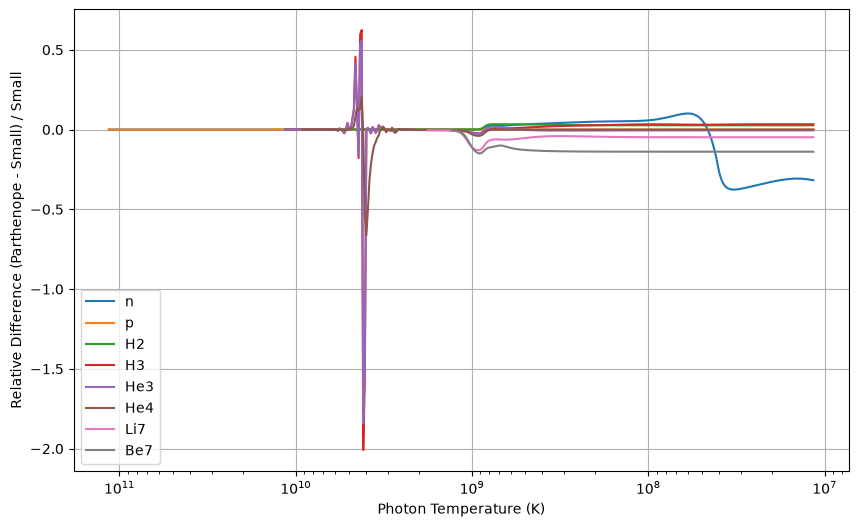

In [4]:
# Plot relative difference of nuclide time evolution
plt.figure(figsize=(10, 6))

ev_small = res_small['evolution']
ev_parthenope = res_parthenope['evolution']

# Use each run's own time grid and the backend-agnostic T_gamma interpolator.
t_small = ev_small.t
t_parthenope = ev_parthenope.t
# T_gamma_interpolator returns MeV; convert to Kelvin for the x-axis label.

T_small = T_gamma_interpolator(ev_small)(t_small) * CONST.MeV_to_Kelvin
T_parthenope = T_gamma_interpolator(ev_parthenope)(t_parthenope) * CONST.MeV_to_Kelvin

for n in nuclides:
    Y_s = Y_interpolator(ev_small, n)(t_small)
    Y_p = Y_interpolator(ev_parthenope, n)(t_parthenope)

    # Interpolate parthenope evolution onto small grid (T decreases with time)
    Y_p_interp = np.interp(T_small, T_parthenope[::-1], Y_p[::-1])

    # Only where the small-network abundance is resolved: below ~1e-25 the
    # ratio is solver noise divided by solver noise.
    mask = Y_s > 1e-25
    rel_diff = (Y_p_interp[mask] - Y_s[mask]) / Y_s[mask]
    plt.plot(T_small[mask], rel_diff, label=n)

plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Photon Temperature (K)")
plt.ylabel("Relative Difference (Parthenope - Small) / Small")
plt.legend()
plt.grid(True)
plt.savefig('plots/compare_small_networks.pdf', bbox_inches='tight')
plt.show()